In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from clustcrdist.neighbors import find_neighbors, neighbor_analysis, compute_sparse_distance_matrix
from clustcrdist.encoding import TCRDistEncoder
from clustcrdist import load_test

from timeit import default_timer as timer
from scipy.sparse import coo_matrix, csr_matrix

# Setting up the plot styles
plt.style.use(['seaborn-v0_8-white', 'seaborn-v0_8-paper'])
plt.rc('font', family='serif')
sns.set_palette('Set1')
sns.set_context('paper', font_scale=1.3)    # single-column figure

print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [4]:
vfreqs = pd.read_table('./data/background/vfrequencies.txt')
cdr3len = pd.read_table('./data/background/cdr3lengths.txt')
df_or = pd.read_table('./data/background/pgen.txt')
df_bg = pd.read_table('./data/background/shuffled_pgen.txt.gz')
df_olga = pd.read_table('./data/background/olga_pgen.txt.gz')

def generate_patches(labels, colors):
    patches = []
    for lab, col in zip(labels, colors):
        patch = mpatches.Patch(color=col, label=lab)
        patches.append(patch)
    return patches

custom_palette = ['#85c1e9','#ec7063','#7dcea0']

## V allele frequencies

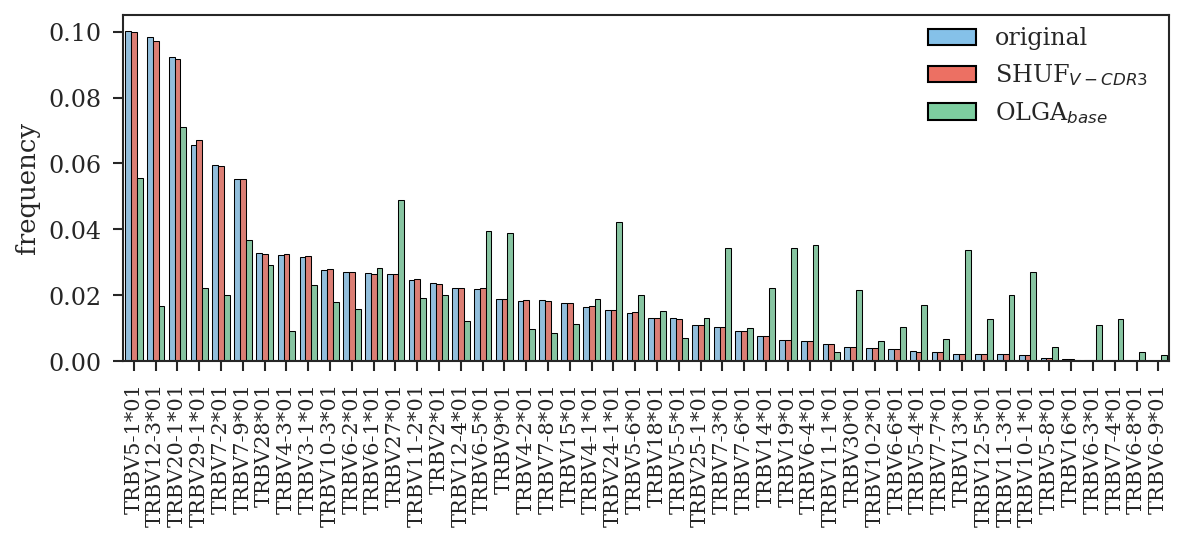

In [5]:
fig, ax = plt.subplots(dpi=150, figsize=(9,3))

# vfreqs = vfreqs.sort_values(by='variable', ascending=False)
sns.barplot(vfreqs, x='v_call', y='value', hue='variable', ax=ax, palette=custom_palette, edgecolor='k', linewidth=0.5)
ax.legend_.remove()
xticks = ax.get_xticklabels()
ax.set_xticklabels(xticks,rotation=90,fontsize=10)

ax.set_ylabel('frequency')
ax.set_xlabel('')

labels = [r'original',r'SHUF$_{V-CDR3}$',r'OLGA$_{base}$']
patches = generate_patches(
    labels=labels,
    colors=['#85c1e9','#ec7063','#7dcea0'],
    )

for patch in patches:
    patch.set_edgecolor('black')  # Set black edge color for each patch
    patch.set_linewidth(1)

fig.legend(patches, labels, bbox_to_anchor=(.9,.9), ncols=1)  # Optional: Set edge line width (thickness)

## CDR3 length distribution

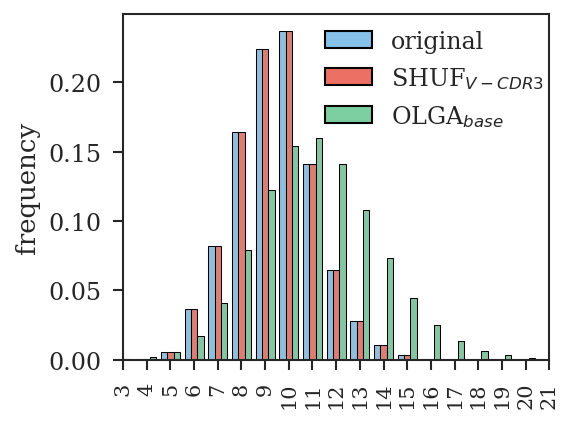

In [6]:
fig, ax = plt.subplots(dpi=150, figsize=(4,3))

# vfreqs = vfreqs.sort_values(by='variable', ascending=False)
sns.barplot(cdr3len, x='length', y='value', hue='variable', ax=ax, palette=custom_palette, edgecolor='k', linewidth=0.5)
ax.legend_.remove()
xticks = ax.get_xticklabels()
ax.set_xticklabels(xticks,rotation=90,fontsize=10)

ax.set_ylabel('frequency')
ax.set_xlabel('')
ax.set_xlim(3,21)

fig.legend(patches, labels, bbox_to_anchor=(.965,.95), ncols=1)
fig.tight_layout()

## Pgen distribution

/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/sebastiaan/miniconda3/envs/knn_tcr/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


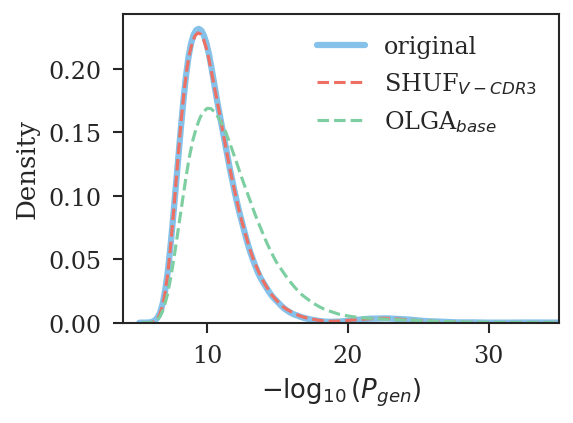

In [7]:
fig, ax = plt.subplots(dpi=150, figsize=(4,3))

sns.kdeplot(-np.log10(df_or.pgen), ax=ax, color=custom_palette[0], linewidth=3, label='original')
sns.kdeplot(-np.log10(df_bg.pgen), ax=ax, color=custom_palette[1], linewidth=1.5, linestyle='--', label=r'SHUF$_{V-CDR3}$')
sns.kdeplot(-np.log10(df_olga.pgen), ax=ax, color=custom_palette[2], linewidth=1.5, linestyle='--', label=r'OLGA$_{base}$')

ax.set_xlim(4,35)
ax.set_xlabel(r'$-\log_{10}(P_{gen})$')

ax.legend()
fig.tight_layout()